# Model Comparison: EfficientNet-B0 vs MobileNetV3-Small

Comparing two transfer learning architectures for plant disease classification on the PlantVillage dataset.

**Research question:** Can a lightweight model suitable for edge deployment match the accuracy of a heavier model?


In [4]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Summary results
models = ['EfficientNet-B0', 'MobileNetV3-Small']
parameters = [4.0, 1.5]
test_accuracy = [99.5, 98.2]
val_acc_epoch1 = [98.48, 96.38]
val_acc_epoch3 = [99.55, 98.22]

print("Model Comparison Summary")
print("=" * 50)
for i, model in enumerate(models):
    print(f"\n{model}")
    print(f"  Parameters:     {parameters[i]}M")
    print(f"  Val Acc Ep1:    {val_acc_epoch1[i]}%")
    print(f"  Val Acc Ep3:    {val_acc_epoch3[i]}%")
    print(f"  Test Accuracy:  {test_accuracy[i]}%")


Model Comparison Summary

EfficientNet-B0
  Parameters:     4.0M
  Val Acc Ep1:    98.48%
  Val Acc Ep3:    99.55%
  Test Accuracy:  99.5%

MobileNetV3-Small
  Parameters:     1.5M
  Val Acc Ep1:    96.38%
  Val Acc Ep3:    98.22%
  Test Accuracy:  98.2%


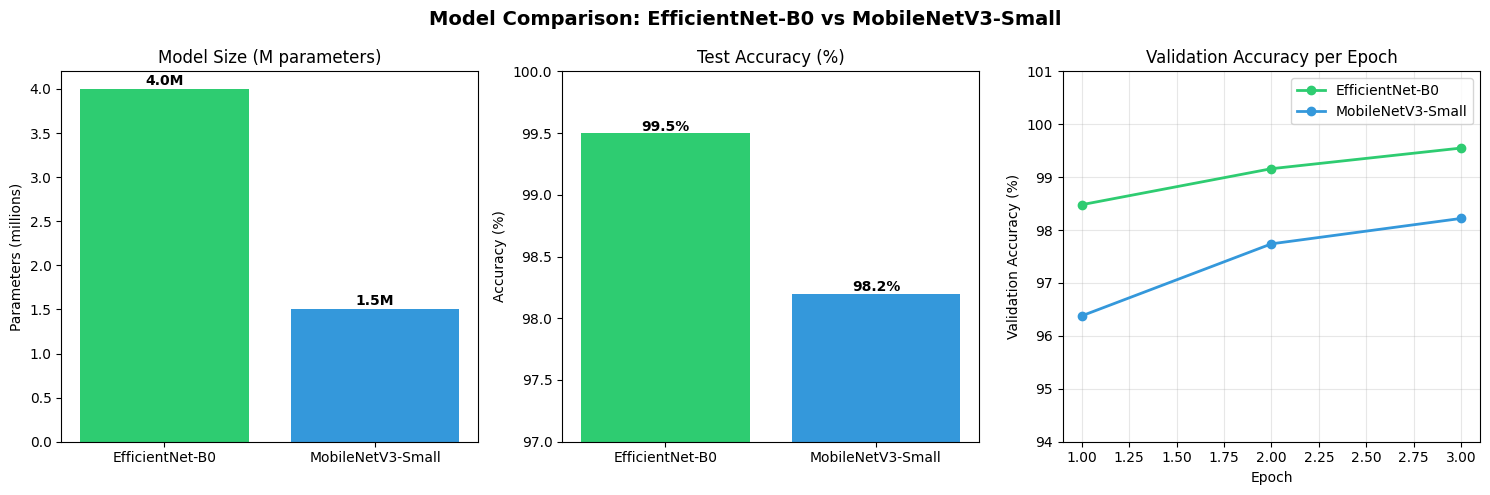

Saved to models/model_comparison.png


In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison: EfficientNet-B0 vs MobileNetV3-Small', fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#3498db']

# Parameters
axes[0].bar(models, parameters, color=colors)
axes[0].set_title('Model Size (M parameters)')
axes[0].set_ylabel('Parameters (millions)')
for i, v in enumerate(parameters):
    axes[0].text(i, v + 0.05, f'{v}M', ha='center', fontweight='bold')

# Test accuracy
axes[1].bar(models, test_accuracy, color=colors)
axes[1].set_title('Test Accuracy (%)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(97, 100)
for i, v in enumerate(test_accuracy):
    axes[1].text(i, v + 0.02, f'{v}%', ha='center', fontweight='bold')

# Accuracy per epoch
epochs = [1, 2, 3]
efficientnet_val = [98.48, 99.16, 99.55]
mobilenet_val = [96.38, 97.74, 98.22]

axes[2].plot(epochs, efficientnet_val, marker='o', color='#2ecc71', label='EfficientNet-B0', linewidth=2)
axes[2].plot(epochs, mobilenet_val, marker='o', color='#3498db', label='MobileNetV3-Small', linewidth=2)
axes[2].set_title('Validation Accuracy per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Validation Accuracy (%)')
axes[2].set_ylim(94, 101)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to models/model_comparison.png")


## Confusion Matrices

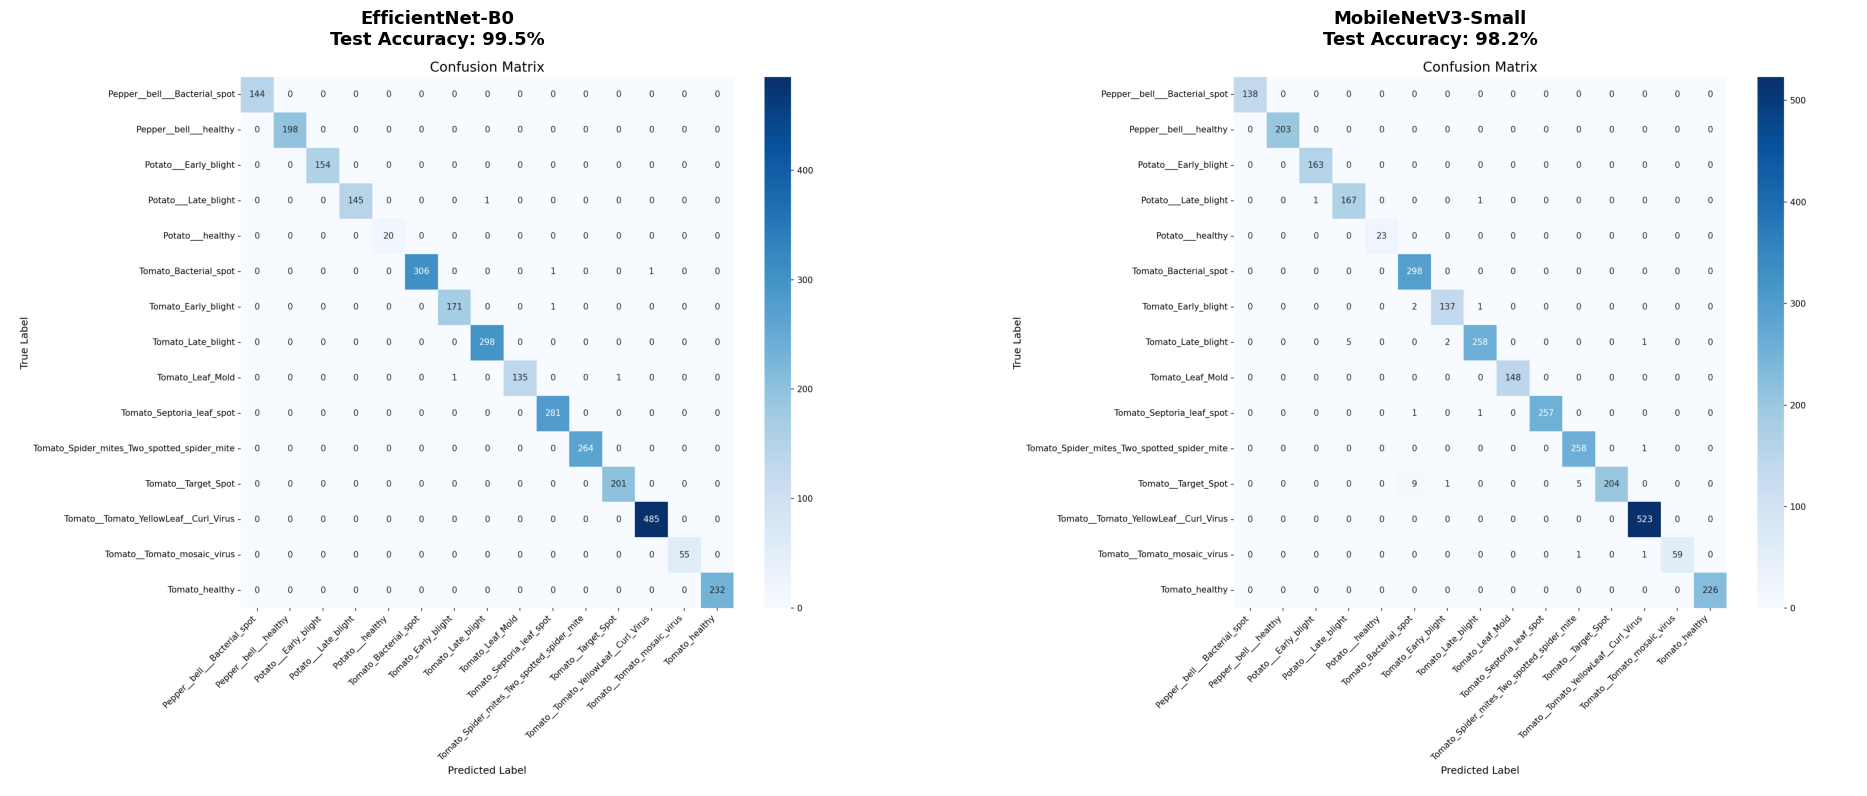

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

efficientnet_cm = mpimg.imread('../models/confusion_matrix.png')
mobilenet_cm = mpimg.imread('../models/confusion_matrix2.png')

axes[0].imshow(efficientnet_cm)
axes[0].set_title('EfficientNet-B0\nTest Accuracy: 99.5%', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mobilenet_cm)
axes[1].set_title('MobileNetV3-Small\nTest Accuracy: 98.2%', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Key Findings

| | EfficientNet-B0 | MobileNetV3-Small |
|---|---|---|
| Parameters | 4.0M | 1.5M |
| Test Accuracy | 99.5% | 98.2% |
| Misclassifications | <5 / 3095 | ~35 / 3095 |
| Val Acc after Epoch 1 | 98.5% | 96.4% |

**Conclusions:**

- MobileNetV3-Small achieves **98.2% accuracy** with **62% fewer parameters** than EfficientNet-B0
- EfficientNet-B0 converges faster � reaching 98.5% after just one epoch vs 96.4% for MobileNetV3
- MobileNetV3 struggles most with visually similar diseases: `Tomato__Target_Spot` vs `Tomato_Bacterial_spot`, and `Tomato_Late_blight` vs `Potato__Late_blight`
- For **edge deployment** (greenhouse camera, mobile device), MobileNetV3-Small offers a compelling tradeoff
- For **high-precision diagnosis** where misclassification is costly, EfficientNet-B0 remains the better choice
